# Setting an energy range for the signal injection

This tutorial shows how to set an energy range for the signal injection and how to visualize the distribution of the generated pseudo-data events.

For analysis setup details check the [Fitting a steady point-source with the public 14-year IceCube track data](fitting_a_source.ipynb) tutorial.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import skyllh
from skyllh.core.config import Config
from skyllh.core.logging import setup_logging
from skyllh.core.source_model import PointLikeSource

cfg = Config()
logger = setup_logging(cfg=cfg, name='setting_an_energy_range')
datasets = skyllh.create_datasets('IceTracks-DR2', cfg=cfg)

# Location of NGC 1068
src_ra = 40.67  # degrees
src_dec = -0.01  # degrees

source = PointLikeSource(ra=np.radians(src_ra), dec=np.radians(src_dec))

2026-05-18 19:59:44,036 MainProcess skyllh.datasets.datasets INFO: Loaded 4 dataset(s) from sample "IceTracks-DR2": IC40, IC59, IC79, IC86_I-XI


The ``create_analysis`` instance can be created with the ``energy_range`` set to a specific energy range. This internally sets the energy range for the signal generator. Here in this example, the analysis object is created with the energy range $10^2\, \text{GeV}$ to $10^3\, \text{GeV}$. 

In [2]:
from skyllh.analyses.i3.publicdata_ps.time_integrated_ps import create_analysis

ana = create_analysis(cfg=cfg, datasets=datasets, source=source, energy_range=(1e2, 1e3))

2026-05-18 19:59:45,125 MainProcess skyllh.analyses.i3.publicdata_ps.time_integrated_ps INFO: SourceHypoGroupManager
    Source Hypothesis Groups:
        0: SourceHypoGroup:
            sources (1):
                0: PointLikeSource: "4544771616": { ra=40.670 deg, dec=-0.010 deg }
            fluxmodel:
                1.000e+00 * (E / (1000 GeV))^-2 * 1 (GeV cm^2 s)^-1
            detector signal yield builders (1):
                PDSingleParamFluxPointLikeSourceI3DetSigYieldBuilder
            signal generation method:
                NoneType
2026-05-18 19:59:45,126 MainProcess skyllh.analyses.i3.publicdata_ps.time_integrated_ps INFO: ParameterModelMapper: 2 global parameters, 2 models (1 source)
    Parameters:        
        ns [floating (0 <= 10 <= 1000)]
            in models:
            - IceCube: ns
                    
        gamma [floating (1 <= 3 <= 4)]
            in models:
            - 4544771616: gamma
            
100%|██████████| 33/33 [00:00<00:00, 509.58it/s

The ``ana`` instance has a ``generate_signal_events`` method, which can be used to generate signal-like pseudo-data. The function takes the ``RandomStateService`` instance and the mean number of events to be generated as its arguments along with a few optional arguments.
The actual number of generated events is drawn from a Poisson distribution with mean value `mean_n_sig`.

It returns:
1. The actual number of generated events;
2. The list of the number of signal events that have been generated for each data set;
3. The list of instance of DataFieldRecordArray containing the signal data events for each data set. An entry is None, if no signal events were generated for this particular data set.

Here below we generate 100 signal-like events:

In [3]:
help(ana.generate_signal_events)

Help on method generate_signal_events in module skyllh.core.analysis:

generate_signal_events(
    rss,
    mean_n_sig,
    sig_kwargs=None,
    n_events_list=None,
    events_list=None,
    tl=None
) method of skyllh.core.analysis.SingleSourceMultiDatasetLLHRatioAnalysis instance
    Generates signal events utilizing the signal generator.

    Parameters
    ----------
    rss : instance of RandomStateService
        The instance of RandomStateService to use for generating random
        numbers.
    mean_n_sig : float
        The mean number of signal events that should be generated for the
        trial. The actual number of generated events will be drawn from a
        Poisson distribution with this given signal mean as mean.
    sig_kwargs : dict | None
        Additional keyword arguments for the ``generate_signal_events``
        method of the ``sig_generator_cls`` class. An usual keyword argument
        is ``poisson``.
    n_events_list : list of int | None
        If given, i

In [4]:
from skyllh.core.random import RandomStateService

mean_n_sig = 100

rss = RandomStateService(seed=1)
n_sig_erange, n_events_list_erange, events_list_erange = ana.generate_signal_events(rss=rss, mean_n_sig=mean_n_sig)

2026-05-18 20:00:00,015 MainProcess skyllh.analyses.i3.publicdata_ps.signal_generator.PDDatasetSignalGenerator WARNING: No `cut_sindec` has been specified. The energy cut will be applied in [-90, 90] deg.
2026-05-18 20:00:00,017 MainProcess skyllh.analyses.i3.publicdata_ps.signal_generator.PDDatasetSignalGenerator WARNING: No `cut_sindec` has been specified. The energy cut will be applied in [-90, 90] deg.
2026-05-18 20:00:00,018 MainProcess skyllh.analyses.i3.publicdata_ps.signal_generator.PDDatasetSignalGenerator WARNING: No `cut_sindec` has been specified. The energy cut will be applied in [-90, 90] deg.
2026-05-18 20:00:00,021 MainProcess skyllh.analyses.i3.publicdata_ps.signal_generator.PDDatasetSignalGenerator WARNING: No `cut_sindec` has been specified. The energy cut will be applied in [-90, 90] deg.
2026-05-18 20:00:00,022 MainProcess skyllh.analyses.i3.publicdata_ps.signal_generator.PDDatasetSignalGenerator WARNING: No `cut_sindec` has been specified. The energy cut will be a

It is also possible to change the energy range to generate signal events without having to reinitialise the analysis instance ``ana``. By re-defining ``ana.energy_range``, one can change what ``ana.generate_signal_events()`` uses as the energy range.

By setting `ana.energy_range` to None, we fall back to the full energy range of the analysis, which is the maximum energy range covered in the _smearing matrix_, that is (1e2 - 1e9) GeV.

In [5]:
rss = RandomStateService(seed=1)
ana.energy_range = None
n_sig, n_events_list, events_list = ana.generate_signal_events(rss=rss, mean_n_sig=mean_n_sig)

2026-05-18 20:00:00,039 MainProcess skyllh.analyses.i3.publicdata_ps.signal_generator.PDDatasetSignalGenerator WARNING: No `cut_sindec` has been specified. The energy cut will be applied in [-90, 90] deg.


2026-05-18 20:00:00,045 MainProcess skyllh.analyses.i3.publicdata_ps.signal_generator.PDDatasetSignalGenerator WARNING: No `cut_sindec` has been specified. The energy cut will be applied in [-90, 90] deg.
2026-05-18 20:00:00,046 MainProcess skyllh.analyses.i3.publicdata_ps.signal_generator.PDDatasetSignalGenerator WARNING: No `cut_sindec` has been specified. The energy cut will be applied in [-90, 90] deg.
2026-05-18 20:00:00,052 MainProcess skyllh.analyses.i3.publicdata_ps.signal_generator.PDDatasetSignalGenerator WARNING: No `cut_sindec` has been specified. The energy cut will be applied in [-90, 90] deg.


Now we can look at the true neutrino energy of the generate pseudo-data events and check that they belong to their respective energy ranges.

In [6]:
print(events_list[0])

DataFieldRecordArray: 11 fields, 3 entries, 1 Kbytes 
    fields = {
        isvalid        : {dtype: bool, vmin: 1.000e+00, vmax: True}
        log_true_energy: {dtype: float64, vmin: 2.208e+00, vmax: 4.61901412729572}
        log_energy     : {dtype: float64, vmin: 3.319e+00, vmax: 4.004816440590243}
        dec            : {dtype: float64, vmin: -1.067e-02, vmax: 0.018836588819249878}
        ra             : {dtype: float64, vmin: 6.821e-01, vmax: 0.6993641866096665}
        sin_dec        : {dtype: float64, vmin: -1.067e-02, vmax: 0.018835474915109864}
        ang_err        : {dtype: float64, vmin: 9.260e-03, vmax: 0.0205442374500656}
        time           : {dtype: float64, vmin: nan, vmax: nan}
        azi            : {dtype: float64, vmin: nan, vmax: nan}
        zen            : {dtype: float64, vmin: nan, vmax: nan}
        run            : {dtype: int64, vmin: -1.000e+00, vmax: -1}
    }


In [7]:
log_true_energy = np.concatenate([events['log_true_energy'] for events in events_list])
injected_log_true_energy = np.concatenate([events['log_true_energy'] for events in events_list_erange])

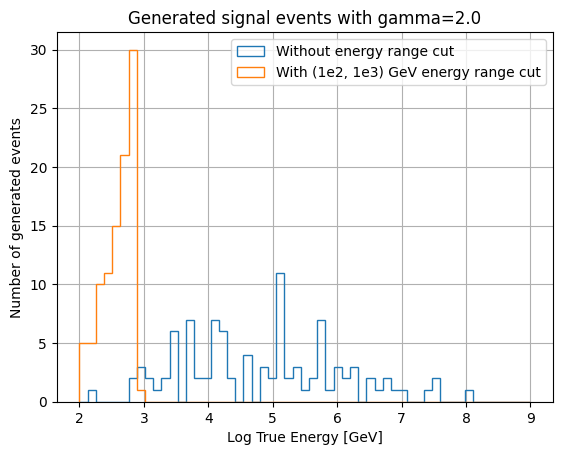

In [8]:
bins = np.linspace(2, 9, 56)

fig, ax = plt.subplots()
ax.hist(log_true_energy, bins=bins, histtype='step', label='Without energy range cut')
ax.hist(
    injected_log_true_energy,
    bins=bins,
    histtype='step',
    label='With (1e2, 1e3) GeV energy range cut',
)
ax.set_title('Generated signal events with gamma=2.0')
ax.set_xlabel('Log True Energy [GeV]')
ax.set_ylabel('Number of generated events')
ax.grid(True)
ax.legend()
plt.show()

It is to be noted that the only thing that is being limited is the injected signal: **We inject signals only in that energy range but the signal hypothesis in the likelihood still assumes the full energy range**.